# Difference-in-Differences: Promotion Effect in Ho Chi Minh City

This notebook starts a difference-in-differences (DiD) analysis to estimate the effect of a promotion on outcomes in Ho Chi Minh City (HCMC). It sets up data ingestion, variable construction, baseline models, checks, and robustness steps.

## 1. Load Libraries and Configure Settings

Import required libraries and set display options for reproducibility and easier inspection.

In [26]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.formula.api as smf

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 120)

SEED = 42
np.random.seed(SEED)

# If you have a preferred plotting style, set it here.
sns.set_theme(style="whitegrid")

## 2. Ingest and Inspect Promotion and Outcome Data

Load datasets, inspect schema, handle missing values, and confirm that time and location fields are correctly typed.

In [27]:
# TODO: Update file paths if you prefer CSV inputs.
# Expected columns (example):
# - city
# - date
# - outcome (e.g., orders, revenue, trips)

import os
import sqlite3

outcomes_path = "data/outcomes.csv"
db_path = "grab_vn_case.db"

if os.path.exists(outcomes_path):
    # Load main outcomes data from CSV
    outcomes = pd.read_csv(outcomes_path)
else:
    if not os.path.exists(db_path):
        raise FileNotFoundError(
            "No outcomes CSV or SQLite DB found. "
            "Set outcomes_path or place grab_vn_case.db in the workspace root."
        )

    # Load from SQLite (preferred for this case study)
    with sqlite3.connect(db_path) as conn:
        outcomes = pd.read_sql_query(
            """
            SELECT
                d.date,
                d.city,
                d.net_gmv_k_vnd,
                d.gross_gmv_k_vnd,
                d.total_discount_k_vnd,
                d.n_transactions,
                d.n_voucher_redemptions,
                w.rainfall_mm
            FROM daily_gmv_summary d
            LEFT JOIN weather_daily w
                ON d.date = w.date AND d.city = w.city
            """,
            conn,
        )

# Inspect schema
print(outcomes.head())
print(outcomes.info())

# Ensure date types
outcomes["date"] = pd.to_datetime(outcomes["date"], errors="coerce")

# Standardize city naming if needed
outcomes["city"] = outcomes["city"].str.strip()

# Basic missing value checks
missing_summary = outcomes.isna().mean().sort_values(ascending=False)
print(missing_summary.head(10))

         date     city  net_gmv_k_vnd  gross_gmv_k_vnd  total_discount_k_vnd  n_transactions  n_voucher_redemptions  \
0  2024-01-01  Da Nang         332.00           332.00                   0.0               9                      0   
1  2024-01-01  Da Nang        1832.92          1832.92                   0.0              51                      0   
2  2024-01-01  Da Nang         632.41           632.41                   0.0              17                      0   
3  2024-01-01  Da Nang         152.75           152.75                   0.0               1                      0   
4  2024-01-01  Da Nang        1895.53          1895.53                   0.0              14                      0   

   rainfall_mm  
0          5.3  
1          5.3  
2          5.3  
3          5.3  
4          5.3  
<class 'pandas.DataFrame'>
RangeIndex: 2642 entries, 0 to 2641
Data columns (total 8 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------

## 3. Define Treatment, Post, and DiD Variables

Create binary indicators for Ho Chi Minh City (treatment), post-promotion period, and their interaction for DiD.

In [28]:
outcomes['city'].value_counts()

city
Hanoi               882
Ho Chi Minh City    882
Da Nang             878
Name: count, dtype: int64

In [29]:
# Promo period in the dataset starts on 2024-02-12 (week 7).
# Adjust if your promo start date differs.
promo_start_date = pd.Timestamp("2024-02-12")

# Choose a single control city: "Hanoi" or "Da Nang"
control_city = "Da Nang"

# Filter to treatment and chosen control only
outcomes = outcomes[
    outcomes["city"].isin(["Ho Chi Minh City", control_city])
].copy()

# Treatment indicator: HCMC vs chosen control city
outcomes["treatment"] = (outcomes["city"].str.lower() == "ho chi minh city").astype(int)

# Post indicator: after promotion start
outcomes["post"] = (outcomes["date"] >= promo_start_date).astype(int)

# DiD interaction
outcomes["did"] = outcomes["treatment"] * outcomes["post"]

# Quick sanity check
outcomes[["city", "date", "treatment", "post", "did"]].head()

,city,date,treatment,post,did
0,Da Nang,2024-01-01,0,0,0
1,Da Nang,2024-01-01,0,0,0
2,Da Nang,2024-01-01,0,0,0
3,Da Nang,2024-01-01,0,0,0
4,Da Nang,2024-01-01,0,0,0


## 4. Estimate Baseline DiD Regression

Fit a linear model with outcome on treatment, post, and interaction; interpret the interaction as the DiD estimate.

In [30]:
# TODO: Replace with your outcome column name if needed.
outcome_col = "net_gmv_k_vnd"

# Baseline DiD regression
model_baseline = smf.ols(
    formula=f"{outcome_col} ~ treatment + post + did",
    data=outcomes,
).fit()

print(model_baseline.summary())

# The coefficient on `did` is the DiD estimate.

                            OLS Regression Results                            
Dep. Variable:          net_gmv_k_vnd   R-squared:                       0.128
Model:                            OLS   Adj. R-squared:                  0.127
Method:                 Least Squares   F-statistic:                     86.00
Date:                Sun, 24 May 2026   Prob (F-statistic):           6.41e-52
Time:                        22:06:19   Log-Likelihood:                -19172.
No. Observations:                1760   AIC:                         3.835e+04
Df Residuals:                    1756   BIC:                         3.837e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept   3006.7826    673.255      4.466      0.0

## 5. Add Covariates and Robust Standard Errors

Extend the model with relevant covariates and compute heteroskedasticity-robust or clustered standard errors.

In [31]:
# TODO: Replace with your covariates.
# Example covariates: rainfall_mm, n_voucher_redemptions, total_discount_k_vnd
covariates = ["rainfall_mm"]

# Keep only covariates present in the data
covariates = [c for c in covariates if c in outcomes.columns]

formula_cov = f"{outcome_col} ~ treatment + post + did"
if covariates:
    formula_cov += " + " + " + ".join(covariates)

model_cov = smf.ols(formula=formula_cov, data=outcomes).fit(
    cov_type="HC1"  # robust SEs
)

print(model_cov.summary())

# For clustered SEs, use: cov_type="cluster", cov_kwds={"groups": outcomes["city"]}

                            OLS Regression Results                            
Dep. Variable:          net_gmv_k_vnd   R-squared:                       0.136
Model:                            OLS   Adj. R-squared:                  0.134
Method:                 Least Squares   F-statistic:                     68.48
Date:                Sun, 24 May 2026   Prob (F-statistic):           6.44e-54
Time:                        22:06:19   Log-Likelihood:                -19164.
No. Observations:                1760   AIC:                         3.834e+04
Df Residuals:                    1755   BIC:                         3.837e+04
Df Model:                           4                                         
Covariance Type:                  HC1                                         
                  coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------
Intercept    2739.9199    210.045     13.044      

In [32]:
# Summarize DiD effect on net GMV

def did_summary(model, label):
    coef = model.params.get("did", np.nan)
    se = model.bse.get("did", np.nan)
    ci_low = coef - 1.96 * se
    ci_high = coef + 1.96 * se
    pval = model.pvalues.get("did", np.nan)
    print(
        f"{label}: did={coef:.2f} (SE={se:.2f}), 95% CI [{ci_low:.2f}, {ci_high:.2f}], p={pval:.3g}"
    )

# Baseline DiD (no covariates)
did_summary(model_baseline, "Baseline")

# DiD with covariates and robust SEs
did_summary(model_cov, "With covariates")

Baseline: did=2920.26 (SE=1256.24), 95% CI [458.04, 5382.48], p=0.0202
With covariates: did=2336.83 (SE=1139.22), 95% CI [103.96, 4569.70], p=0.0402


## 6. Validate Parallel Trends with Pre-Treatment Checks

Subset to pre-promotion periods and test for differential trends between treatment and control.

In [33]:
# Pre-treatment subset
pre = outcomes[outcomes["date"] < promo_start_date].copy()

# Create a time index for trend testing (e.g., week number)
pre = pre.sort_values("date")
pre["time_index"] = pre["date"].rank(method="dense").astype(int)

# Interact treatment with time to test differential pre-trends
pre_model = smf.ols(
    formula=f"{outcome_col} ~ treatment + time_index + treatment:time_index",
    data=pre,
).fit(cov_type="HC1")

print(pre_model.summary())

# A statistically insignificant treatment:time_index supports parallel trends.

                            OLS Regression Results                            
Dep. Variable:          net_gmv_k_vnd   R-squared:                       0.151
Model:                            OLS   Adj. R-squared:                  0.147
Method:                 Least Squares   F-statistic:                     44.54
Date:                Sun, 24 May 2026   Prob (F-statistic):           1.72e-26
Time:                        22:06:20   Log-Likelihood:                -7960.4
No. Observations:                 753   AIC:                         1.593e+04
Df Residuals:                     749   BIC:                         1.595e+04
Df Model:                           3                                         
Covariance Type:                  HC1                                         
                           coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------
Intercept             2999.4644 

## 7. Visualize DiD Effects and Event Study

Plot group trends over time and estimate an event-study specification with leads and lags.

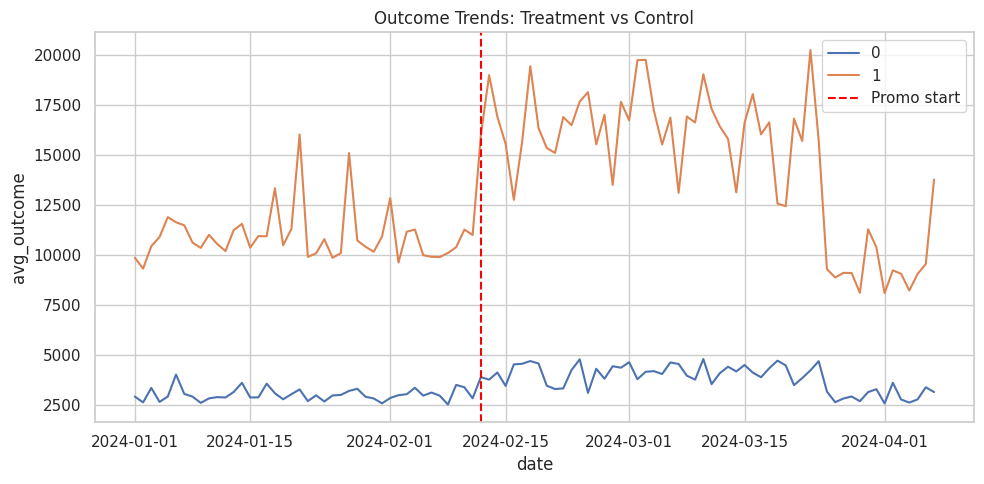

                            OLS Regression Results                            
Dep. Variable:          net_gmv_k_vnd   R-squared:                       0.139
Model:                            OLS   Adj. R-squared:                  0.124
Method:                 Least Squares   F-statistic:                     9.453
Date:                Sun, 24 May 2026   Prob (F-statistic):           2.17e-39
Time:                        22:06:21   Log-Likelihood:                -19162.
No. Observations:                1760   AIC:                         3.839e+04
Df Residuals:                    1729   BIC:                         3.855e+04
Df Model:                          30                                         
Covariance Type:                  HC1                                         
                                                             coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------

In [34]:
# Aggregate outcomes by date and treatment status
trend = (
    outcomes.groupby(["date", "treatment"], as_index=False)[outcome_col]
    .mean()
    .rename(columns={outcome_col: "avg_outcome"})
)

plt.figure(figsize=(10, 5))
sns.lineplot(data=trend, x="date", y="avg_outcome", hue="treatment")
plt.axvline(promo_start_date, color="red", linestyle="--", label="Promo start")
plt.title("Outcome Trends: Treatment vs Control")
plt.legend()
plt.tight_layout()
plt.show()

# Event study (simple version): leads and lags around promo
outcomes = outcomes.sort_values("date")
outcomes["event_time"] = (outcomes["date"] - promo_start_date).dt.days

# Bucket into weekly bins for stability
outcomes["event_week"] = (outcomes["event_time"] / 7).round().astype(int)

# Keep a manageable window
outcomes = outcomes[outcomes["event_week"].between(-8, 8)].copy()

baseline_week = -1

# Use categorical event_week with a reference period to avoid invalid column names
ref_term = f"C(event_week, Treatment(reference={baseline_week}))"

event_formula = (
    f"{outcome_col} ~ treatment + post + {ref_term} + treatment:{ref_term}"
)

event_model = smf.ols(event_formula, data=outcomes).fit(cov_type="HC1")
print(event_model.summary())

## 8. Sensitivity and Placebo Tests

Run placebo treatments or alternative post periods to assess robustness of the DiD estimate.

In [19]:
# Placebo: shift promo start earlier and re-estimate
placebo_start = promo_start_date - pd.Timedelta(days=30)

outcomes["post_placebo"] = (outcomes["date"] >= placebo_start).astype(int)
outcomes["did_placebo"] = outcomes["treatment"] * outcomes["post_placebo"]

placebo_model = smf.ols(
    formula=f"{outcome_col} ~ treatment + post_placebo + did_placebo",
    data=outcomes,
).fit(cov_type="HC1")

print(placebo_model.summary())

# Alternative post window sensitivity
# Example: only use +/- 60 days around promo start
window = 60
window_data = outcomes[
    (outcomes["date"] >= promo_start_date - pd.Timedelta(days=window))
    & (outcomes["date"] <= promo_start_date + pd.Timedelta(days=window))
].copy()

window_model = smf.ols(
    formula=f"{outcome_col} ~ treatment + post + did",
    data=window_data,
).fit(cov_type="HC1")

print(window_model.summary())

                            OLS Regression Results                            
Dep. Variable:          net_gmv_k_vnd   R-squared:                       0.002
Model:                            OLS   Adj. R-squared:                  0.000
Method:                 Least Squares   F-statistic:                    0.6866
Date:                Sun, 24 May 2026   Prob (F-statistic):              0.408
Time:                        22:03:44   Log-Likelihood:                -9889.7
No. Observations:                 882   AIC:                         1.979e+04
Df Residuals:                     879   BIC:                         1.980e+04
Df Model:                           2                                         
Covariance Type:                  HC1                                         
                   coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept     6.884e+16   8.31e+16      0.829   

/home/duy/project/grab_assignment/.venv/lib/python3.12/site-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 3, but rank is 1
  warnings.warn('covariance of constraints does not have full '
/home/duy/project/grab_assignment/.venv/lib/python3.12/site-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 3, but rank is 2
  warnings.warn('covariance of constraints does not have full '
